# Recap


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Recap en uitbreiding

In Q1 heb je geleerd om een botsend deeltjes model te maken, startend met 1 of 2 deeltjes en dit vervolgens uitbreidend naar ~100 deeltjes. Daarbij was het logisch om gebruik te maken van classes.

Logischerwijs zou onze simulatie de volgende stappen doorlopen:
1. bepalen van initiële condities
2. definiëren van de deeltjes
3. definiëren van volume met randvoorwaarden
4. simulaties bestaande uit:
    - bepaling van positie van deeltjes
    - controleren op onderlinge botsingen 
    - controleren op botsingen met wanden
    - aanpassen van eigenschappen zoals totaal volume of temperatuur
    - opslaan van gegevens
    
```{note}
Alhoewel het interessant is om steeds een animatie te maken van de beweging van de deeltjes, vraagt dit veel rekentijd. Je zou ook regelmatig een plot kunnen laten maken om te controleren of het programma werkt zoals je zou mogen verwachten.
```

### De initiële condities

In onze simulatie gaan we uit van een aantal aannames. Bij deze aannames wil je dat de simulatie een voorspellende waarde heeft voor een reëel systeem, maar ook dat de benodigde rekenkracht voor het uitvoeren van de simulatie op te brengen is. We kiezen daarom voor de volgende condities:

- Ons model heeft een beperkt en constant aantal deeltjes.
- We maken gebruik van een 2D simulatie.
- De deeltjes voelen geen onderlinge kracht en ondergaan alleen elastische botsingen.
- (gevolg) De tijdstap is voldoende klein (d.w.z. de afgelegde weg $v_0*dt$ is klein in vergelijking met de diameter van de deeltjes, zodat we geen botsingen missen).

Hieronder geven we een aantal constanten voor onze code. Om de simulatie straks te kunnen interpreteren, vergelijken we deze eerst met een realistische situatie:

```{exercise}
Als model gaan we uit van een deel van het volume van een fietsband die onder een druk van 10 atmosfeer staat. Schat hiervoor het gemiddelde volume $V_{molecuul}$ en de gemiddelde snelheid per gasmolecuul. 
```

Deze simulatie bevat maar twee dimensies. We kunnen het oppervlak per deeltje in deze simulatie daarom kiezen als het zojuist berekende $V_{molecuul}^{2/3}$.

```{exercise}
Geef de eenheden (met vermenigvuldigingsfactor) voor de constanten `N` en `V_0` in de hieronder gegeven code waarbij de simulatie een redelijk tweedimensionaal model is voor de fietsband.
```

```{exercise}
Je weet nu wat de schaal is waarop `N` en `V_0` gegeven zijn. Pas waarde van `RADIUS` en `DT` aan om deze hiermee in overeenstemming te krijgen.
```

Onze simulatie modelleert dus een klein systeem zonder rekening te houden met de kracht tussen de luchtmoleculen. Je zult zien dat we toch al behoorlijk wat van de processor vragen om deze berekeningen te doen. Om een realistische modelsimulatie te maken is daarom een serieuze uitdaging, die veel wiskunde en programmeerervaring vraagt.

In [2]:
# Aanmaken van de randvoorwaarden en initiële condities
BOX_SIZE_0 = 30                                             # Hoogte en breedte startvolume
BOX_LENGTH_0 = BOX_SIZE_0 / 2
N = 400                                                     # Aantal deeltjes
V_0 = 1                                                     # Startsnelheid van deeltjes
RADIUS = 0.3 # pas aan                                      # Straal van moleculen
DT = 0.1 * RADIUS / V_0                                     # Tijdstap simulatie om aan conditie te voldoen


### Particle class
Ons `ParticleClass` definieert van een deeltje de massa $m$, snelheid $v$, positie $r$, en straal $R$. De positie moet per tijdstap bepaald worden. 

Nieuw aan `ParticleClass` zijn twee properties, nl. `momentum` en `energy`. Een property is eigenlijk een variabele die samenhangt met de waarde van andere variabelen binnen de klasse. Om de interne consistentie te bewaren moet je de juiste waarde van deze variabele dus telkens afleiden en dat doe je met een functie. Zo geeft `kin_energy` de kinetische energie terug van het deeltje door die af te leiden van de variabelen `m` en `v`.

Daarnaast voegen we twee functies toe, die je ook al hebt gezien. De eerste heet `collide_detection` en detecteert of twee deeltjes onderling overlappen en dus botsen. De tweede heet `particle_collision` en berekent de nieuwe snelheden van de twee deeltjes ten gevolge van hun botsing.

In [3]:
# Maken van de class
class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = R

    # Het updaten van de positie
    def update_position(self):
        self.r += self.v * DT 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
# Het bepalen of er een botsing plaats vindt
def collide_detection(p1: ParticleClass, p2: ParticleClass) -> bool:
    return np.linalg.norm(p1.r - p2.r) < (p1.R + p2.R)

# Snelheden van paar deeltjes aanpassen ten gevolge van botsing
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    r1, r2 = p1.r, p2.r
    v1, v2 = p1.v, p2.v
    m1, m2 = p1.m, p2.m
    delta_r = r1 - r2
    delta_v = v1 - v2
    if np.dot(delta_r, delta_v) > 0:                        # Als deeltjes van elkaar weg bewegen
        return                                              # dan geen botsing en snelheden zo houden
    distance_squared = np.dot(delta_r, delta_r) + 1e-12     # voorkom deling door 0
    # Botsing oplossen volgens elastische botsing in 2D
    v1_new = v1 - 2 * m2 / (m1 + m2) * np.dot(delta_v, delta_r) / distance_squared * delta_r
    v2_new = v2 - 2 * m1 / (m1 + m2) * np.dot(-delta_v, -delta_r) / distance_squared * (-delta_r)
    p1.v = v1_new
    p2.v = v2_new

### Volume en randvoorwaarden

Voor het volume maken we gebruik van een plot, net zoals we dat in Q1 gedaan hebben. Daar is op dit ogenblik niets anders voor nodig dan een functie die de deeltjes laat botsen met de wanden. Ook deze functie heb je al gezien in Q1.

In [4]:
box_length = BOX_LENGTH_0     # De grootte van de box kan wijzigen!

#### Bepaling positie deeltjes

Eerst moeten we alle deeltjes aanmaken en de startwaardes van hun variabelen invoeren:


```{exercise}
Leg uit dat d.m.v. onderstaande code de deeltjes allemaal dezelfde snelheid hebben en uniform verdeeld zijn over de box.
```

In [5]:
particles = []

# Aanmaken van deeltjes
for i in range(N):
    vx = np.random.uniform(-V_0, V_0)
    vy = np.random.choice([-1, 1]) * np.sqrt(V_0**2 - vx**2)        
    pos = BOX_LENGTH_0 * np.random.uniform(-1, 1, 2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r=pos, R=RADIUS))

#### Controleren op onderlinge botsingen

Om de botsingen tussen alle deeltjes goed te verwerken moeten we controleren welke paren deeltjes met elkaar moeten botsen en deze botsingen één keer uitvoeren:

In [6]:
def handle_collisions(particles):
    ignore_list = []
    for p1 in particles:
        if p1 in ignore_list:                                   # overslaan als partner al geweest is
            continue
        for p2 in particles:
            if p1 is p2:
                continue
            if collide_detection(p1, p2):
                particle_collision(p1, p2)
                ignore_list.append(p2)                          # partner uitsluiten van de berekening

#### Controleren op botsingen met wanden

Voor het bepalen of deeltjes botsen met de wanden maken we ook gebruik van een functie die je al in Q1 gezien hebt.

In [7]:
# Harde wand
def box_collision(particle: ParticleClass):
    if abs(particle.r[0]) + particle.R > box_length: 
        particle.v[0] = -particle.v[0]                                      # Omdraaien van de snelheid
        particle.r[0] = np.sign(particle.r[0]) * (box_length - particle.R)  # Zet terug net binnen box                 
    if abs(particle.r[1]) + particle.R > box_length: 
        particle.v[1] = -particle.v[1]     
        particle.r[1] = np.sign(particle.r[1]) * (box_length - particle.R) 

### Deel 3: draaien van de simulatie

Hier een tekst over het draaien van de simulatie

In [8]:
for i in range(100):
    for p in particles:
        p.update_position()
        box_collision(p)  # Wandbotsing werkt per deeltje
    handle_collisions(particles)

Zoals aangegeven, we kunnen een animatie maken van de positie en snelheid als functie van de tijd, maar we kunnen ook het eindresultaat tonen en interpreteren:

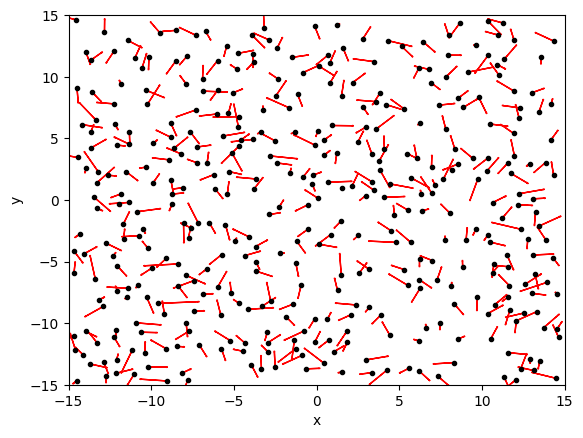

In [9]:
plt.figure()
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-BOX_LENGTH_0, BOX_LENGTH_0)
plt.ylim(-BOX_LENGTH_0, BOX_LENGTH_0)


for particle_object in particles:
    plt.plot(particle_object.r[0], particle_object.r[1], 'k.')
    plt.arrow(particle_object.r[0], particle_object.r[1], 
              particle_object.v[0], particle_object.v[1], 
              head_width=0.05, head_length=0.1, color='red')
plt.show()